In [2]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)

### 1. Helper functions to create branch lengths for phylogenetic trees

In [3]:
# helper function to create the branch lengths for a pectinate tree with n tips

pectinate_branch_lengths <- function(n, mu, r) {
    set.seed(r)
    id_branch_lengths = rexp(n - 1, rate = mu)
    branch_lengths = rep(0, 2 * (n - 1))
    branch_lengths[2 * (n - 1)] = id_branch_lengths[n - 1]
    branch_lengths[2 * n - 3] = id_branch_lengths[n - 1]
    for (i in (n - 2):1) {
        branch_lengths[2 * i] = id_branch_lengths[i]
        branch_lengths[2 * i - 1] = branch_lengths[2 * i + 1] +  branch_lengths[2 * i]
    }
    return(branch_lengths)
}

In [4]:
# helper function to create the branch lengths for a balanced tree with n tips

balanced_branch_lengths <- function(n, mu, r) {
    set.seed(r)
    d = log2(n)
    
    id_branch_lengths = rexp(n - 1, rate = mu)
    branch_lengths = rep(0, 2 * (n - 1))
    
    gaps = 1
    for (i in 2:d) {
        gaps = c(gaps, i, gaps)
    }
    gaps = c(0, gaps)
    for (i in 2:length(gaps)) {
        gaps[i] = gaps[i - 1] + gaps[i]
    }
    branches = gaps + d
    branch_lengths[branches] = rep(id_branch_lengths[1:(n / 2)], each = 2)
    t = id_branch_lengths[1:(n / 2)]
    id_branch_lengths = id_branch_lengths[-(1:(n / 2))]

    for (i in (d - 1):1) {
        branches = branches[seq(1, length(branches), by = 2)] - 1
        branch_lengths[branches] = rep(id_branch_lengths[1:(2 ** (i - 1))], each = 2)
        tl = t[seq(1, length(t), by = 2)]
        tr = t[seq(2, length(t), by = 2)]
        t_matrix = matrix(c(tl, tr), nrow = 2, byrow = TRUE)
        t_max = apply(t_matrix, 2, max)
        dt = rep(t_max, each = 2) - t
        branch_lengths[branches] = branch_lengths[branches] + dt
        
        id_branch_lengths = id_branch_lengths[-(1:(2 ** (i - 1)))]
        t = tl + branch_lengths[branches[seq(1, length(branches), by = 2)]]      
    }
    return(branch_lengths)
}

### 2. Showing the performance of VCV and dcVCV

In [5]:
num_rep = 500
n_tips = 128
num_PC = 50
n_rows = (1 + num_PC) * num_rep * 4

In [6]:
# Yule trees
p_vals_PC_yule = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=rep(c("lm", "phylolm"), times = n_rows / 2), 
    matrix=rep(c("VCV", "VCV", "dcVCV", "dcVCV"), times = n_rows / 4)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    set.seed(i)
    
    tree = sim.bd.taxa(n_tips,1,1,0,1,complete=FALSE)[[1]]
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)

    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = X * 0.5 + BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_yule[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                     "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_yule[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                     "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_yule[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                     "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_yule[counter, `:=`("PCs" = j - 1, "p.value" = cur_p,  
                                     "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
        
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [7]:
p_vals_PC_summary_yule = p_vals_PC_yule %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_yule$method_matrix = interaction(p_vals_PC_summary_yule$method, 
                                                   p_vals_PC_summary_yule$matrix, 
                                                   sep = "_")

In [17]:
plot_1 <- p_vals_PC_summary_yule %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  theme(legend.position=c(.85,.15),legend.spacing.y = unit(1,"pt")) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

In [12]:
# Pectinate trees
p_vals_PC_pectinate = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=rep(c("lm", "phylolm"), times = n_rows / 2), 
    matrix=rep(c("VCV", "VCV", "dcVCV", "dcVCV"), times = n_rows / 4)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    set.seed(i)
    
    tree = PectinateTree(n_tips)
    tree$edge.length = pectinate_branch_lengths(n_tips, 1, i)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)

    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = X * 0.5 + BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_pectinate[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                          "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        tryCatch({
            cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_pectinate[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                              "method" = "phylolm", "matrix" = "VCV")]
        }, error = function(e) {
            p_vals_PC_pectinate[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                              "method" = "phylolm", "matrix" = "VCV")]
        })

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_pectinate[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                          "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_pectinate[counter, `:=`("PCs" = j - 1, "p.value" = cur_p,  
                                          "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
        
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [13]:
p_vals_PC_summary_pectinate = p_vals_PC_pectinate %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_pectinate$method_matrix = interaction(p_vals_PC_summary_pectinate$method, 
                                                        p_vals_PC_summary_pectinate$matrix, 
                                                        sep = "_")

In [23]:
options(repr.plot.width = 8, repr.plot.height = 8)

plot_2 <- p_vals_PC_summary_pectinate %>%
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  theme(legend.position=c(.85,.15),legend.spacing.y = unit(1,"pt")) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

Warning message:
“Removed 26 rows containing missing values or values outside the scale range (`geom_line()`).”


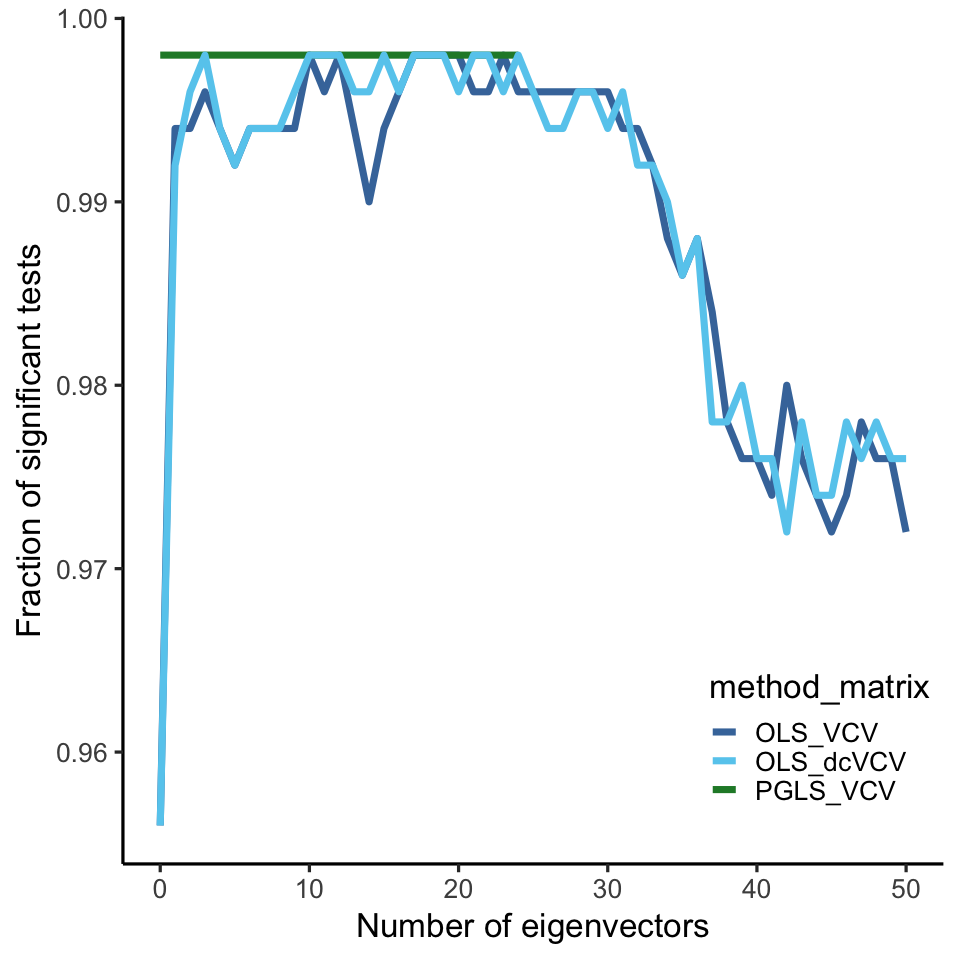

In [21]:
options(repr.plot.width = 8, repr.plot.height = 8)

plot_2_check <- p_vals_PC_summary_pectinate %>% filter(method_matrix != "PGLS_dcVCV") %>%
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  theme(legend.position=c(.85,.15),legend.spacing.y = unit(1,"pt")) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV"))

plot_2_check

In [22]:
# Balanced trees
p_vals_PC_balanced = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=rep(c("lm", "phylolm"), times = n_rows / 2), 
    matrix=rep(c("VCV", "VCV", "dcVCV", "dcVCV"), times = n_rows / 4)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    set.seed(i)
    
    tree = BalancedTree(n_tips)
    tree$edge.length = balanced_branch_lengths(n_tips, 1, i)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)

    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = X * 0.5 + BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_balanced[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                         "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_balanced[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                         "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_balanced[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                         "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_balanced[counter, `:=`("PCs" = j - 1, "p.value" = cur_p,  
                                         "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
        
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [24]:
p_vals_PC_summary_balanced = p_vals_PC_balanced %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_balanced$method_matrix = interaction(p_vals_PC_summary_balanced$method, 
                                                       p_vals_PC_summary_balanced$matrix, 
                                                       sep = "_")

In [25]:
plot_3 <- p_vals_PC_summary_balanced %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  theme(legend.position=c(.85,.15),legend.spacing.y = unit(1,"pt")) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

In [26]:
# Coalescent trees
p_vals_PC_coal = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=rep(c("lm", "phylolm"), times = n_rows / 2), 
    matrix=rep(c("VCV", "VCV", "dcVCV", "dcVCV"), times = n_rows / 4)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    set.seed(i)
    
    tree = rcoal(n_tips)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)

    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = X * 0.5 + BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_coal[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                     "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_coal[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                     "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_coal[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                     "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_coal[counter, `:=`("PCs" = j - 1, "p.value" = cur_p,  
                                     "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
        
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [27]:
p_vals_PC_summary_coal = p_vals_PC_coal %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_coal$method_matrix = interaction(p_vals_PC_summary_coal$method, 
                                                   p_vals_PC_summary_coal$matrix, 
                                                   sep = "_")

In [28]:
plot_4 <- p_vals_PC_summary_coal %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  theme(legend.position=c(.85,.15),legend.spacing.y = unit(1,"pt")) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

Warning message:
“Removed 26 rows containing missing values or values outside the scale range (`geom_line()`).”


TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]
2 2 (2-2,1-1) arrange gtable[arrange]

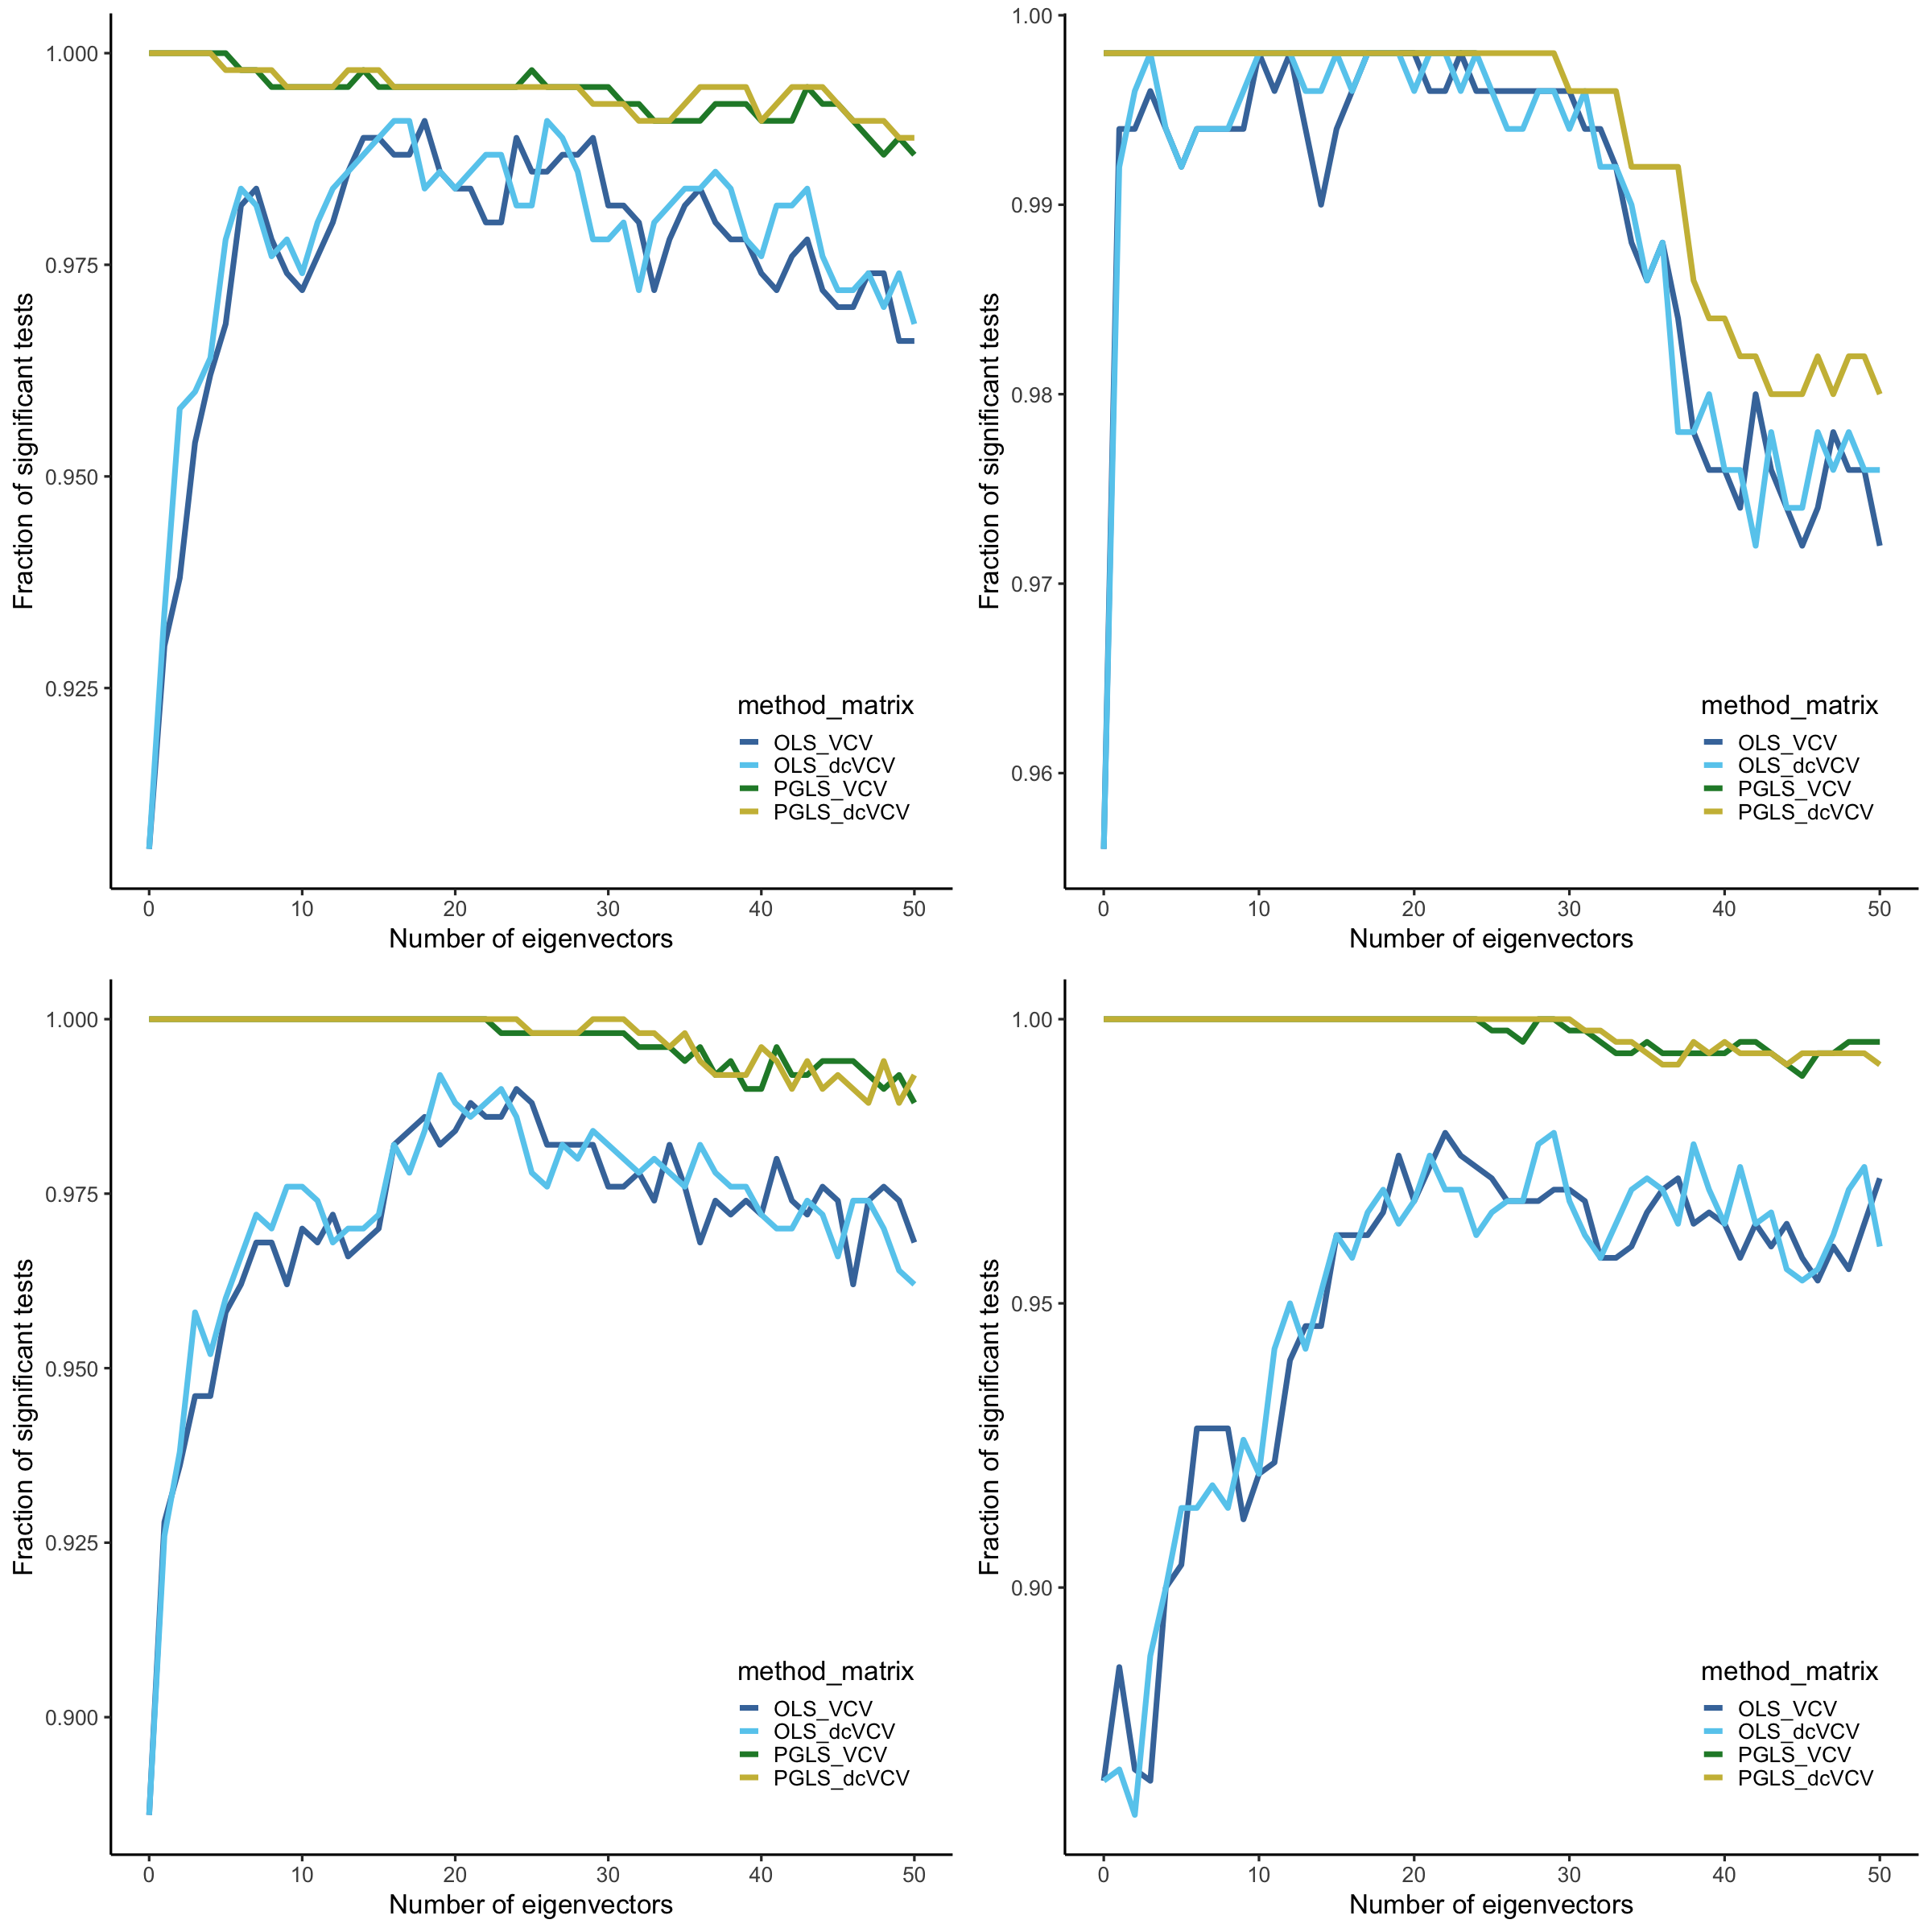

In [29]:
options(repr.plot.width = 20, repr.plot.height = 20)

row1 <- arrangeGrob(plot_1, plot_2, ncol = 2)
row2 <- arrangeGrob(plot_3, plot_4, ncol = 2)

# Arrange all rows into one layout
g <- grid.arrange(row1, row2, nrow = 2)
g
ggsave("Figures_raw/Supplmentary_VCV_dcVCV_positive_1.pdf", g, width = 20, height = 20)
ggsave("Figures_raw/Supplmentary_VCV_dcVCV_positive_1.svg", g, width = 20, height = 20)

### 3. Testing the scaling effect

In [30]:
num_rep = 100
n_tips = 2 ** c(3:10)
n_PCs = n_tips / 2 - 1
n_PCs [n_PCs > 50] = 50
n_size = length(n_tips)
betas = 2 ** c(-4:4)
n_beta = length(betas)
n_rows = num_rep * (sum(n_PCs) + n_size) * n_beta * 2

In [31]:
p_vals_PC = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=rep(c("lm", "phylolm"), times = n_rows / 2), 
    n.tips=numeric(n_rows), 
    beta.size=numeric(n_rows)
)

set.seed(42)

counter = 1
for (i in 1:n_size) {
    message("Testing for tip number: ", i)
    n_tip = n_tips[i]
    n_PC = n_PCs[i]

    tree = sim.bd.taxa(n_tip,1,1,0,1,complete=FALSE)[[1]]
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)

    
    PC_sets = lapply(1:n_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets) 

    for (j in 1:num_rep) {
        if (j %% 10 == 0) {message("repeat: ", j)}
        
        for (k in 1:n_beta) {
            beta = betas[k]

            BM = fastBM(tree,1,nsim=2)
            X = BM[,1]
            Y = X * beta + BM[,2]
    
            all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
            rownames(all_data) = rownames(BM)
            

            for (l in 1:length(PC_sets)) {
                cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
                
                cur_lm = lm(cur_formula,data=all_data)
                cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

                p_vals_PC[counter, `:=`("PCs" = l - 1, "p.value" = cur_p, "method" = "lm", 
                                        "n.tips" = n_tip, "beta.size" = beta)]

                counter = counter + 1
                
                tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]
                          
                    p_vals_PC[counter, `:=`("PCs" = l - 1, "p.value" = cur_p, "method" = "phylolm", 
                                            "n.tips" = n_tip, "beta.size" = beta)]
                }, error = function(e) { 
                    
                    p_vals_PC[counter, `:=`("PCs" = l - 1, "p.value" = NA, "method" = "phylolm", 
                                            "n.tips" = n_tip, "beta.size" = beta)]
                 })

                counter = counter + 1
           }      
            
       }
    
    }
}

Testing for tip number: 1

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

repeat: 80

repeat: 90

repeat: 100

Testing for tip number: 2

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

repeat: 80

repeat: 90

repeat: 100

Testing for tip number: 3

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

repeat: 80

repeat: 90

repeat: 100

Testing for tip number: 4

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

repeat: 80

repeat: 90

repeat: 100

Testing for tip number: 5

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

repeat: 80

repeat: 90

repeat: 100

Testing for tip number: 6

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

repeat: 80

repeat: 90

repeat: 100

Testing for tip number: 7

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

r

In [32]:
fwrite(p_vals_PC, file = "p_vals_PC_positive_Yule_1.csv")

In [33]:
plot_positive_yule_list = vector("list", 9)

for (i in 1:9) {
    beta = 2 ** (i - 5) 
    p_vals_PC_summary_yule = (p_vals_PC %>%
        filter(beta.size == beta) %>%
        group_by(method, PCs, n.tips) %>%
        summarise(FNR = mean(p.value<0.05), .groups = "drop") %>%
        mutate(method=ifelse(method=="phylolm","PGLS","OLS")))
    
    p_vals_PC_summary_yule$n.tips = factor(p_vals_PC_summary_yule$n.tips)
    p_vals_PC_summary_yule$method = factor(p_vals_PC_summary_yule$method)

    plot_positive_yule_list[[i]] <- (p_vals_PC_summary_yule %>% 
          ggplot(aes(PCs,FNR)) +
          geom_line(aes(color = n.tips, linetype = method), linewidth=2) +
          theme_classic(base_size=20) +
          xlab("Number of eigenvectors") +
          ylab("Fraction of significant tests") + 
          ylim(0, 1) +
          theme(legend.position=c(.88,.25), legend.spacing.y = unit(1,"pt"), 
                legend.key.width = unit(2, "cm"),
                axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
                axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
                legend.title = element_text(size = 24), legend.text = element_text(size = 18)) +
          scale_color_manual(values=c("#332288", "#88CCEE", "#44AA99", "#117733",
                                      "#999933", "#DDCC77", "#CC6677", "#882255"), 
                             breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
          scale_linetype_manual(values = c("solid", "twodash"), breaks = c("OLS", "PGLS")) +
          guides(color = guide_legend(order = 2),
              linetype = guide_legend(order = 1)))
}

TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]
2 2 (2-2,1-1) arrange gtable[arrange]
3 3 (3-3,1-1) arrange gtable[arrange]

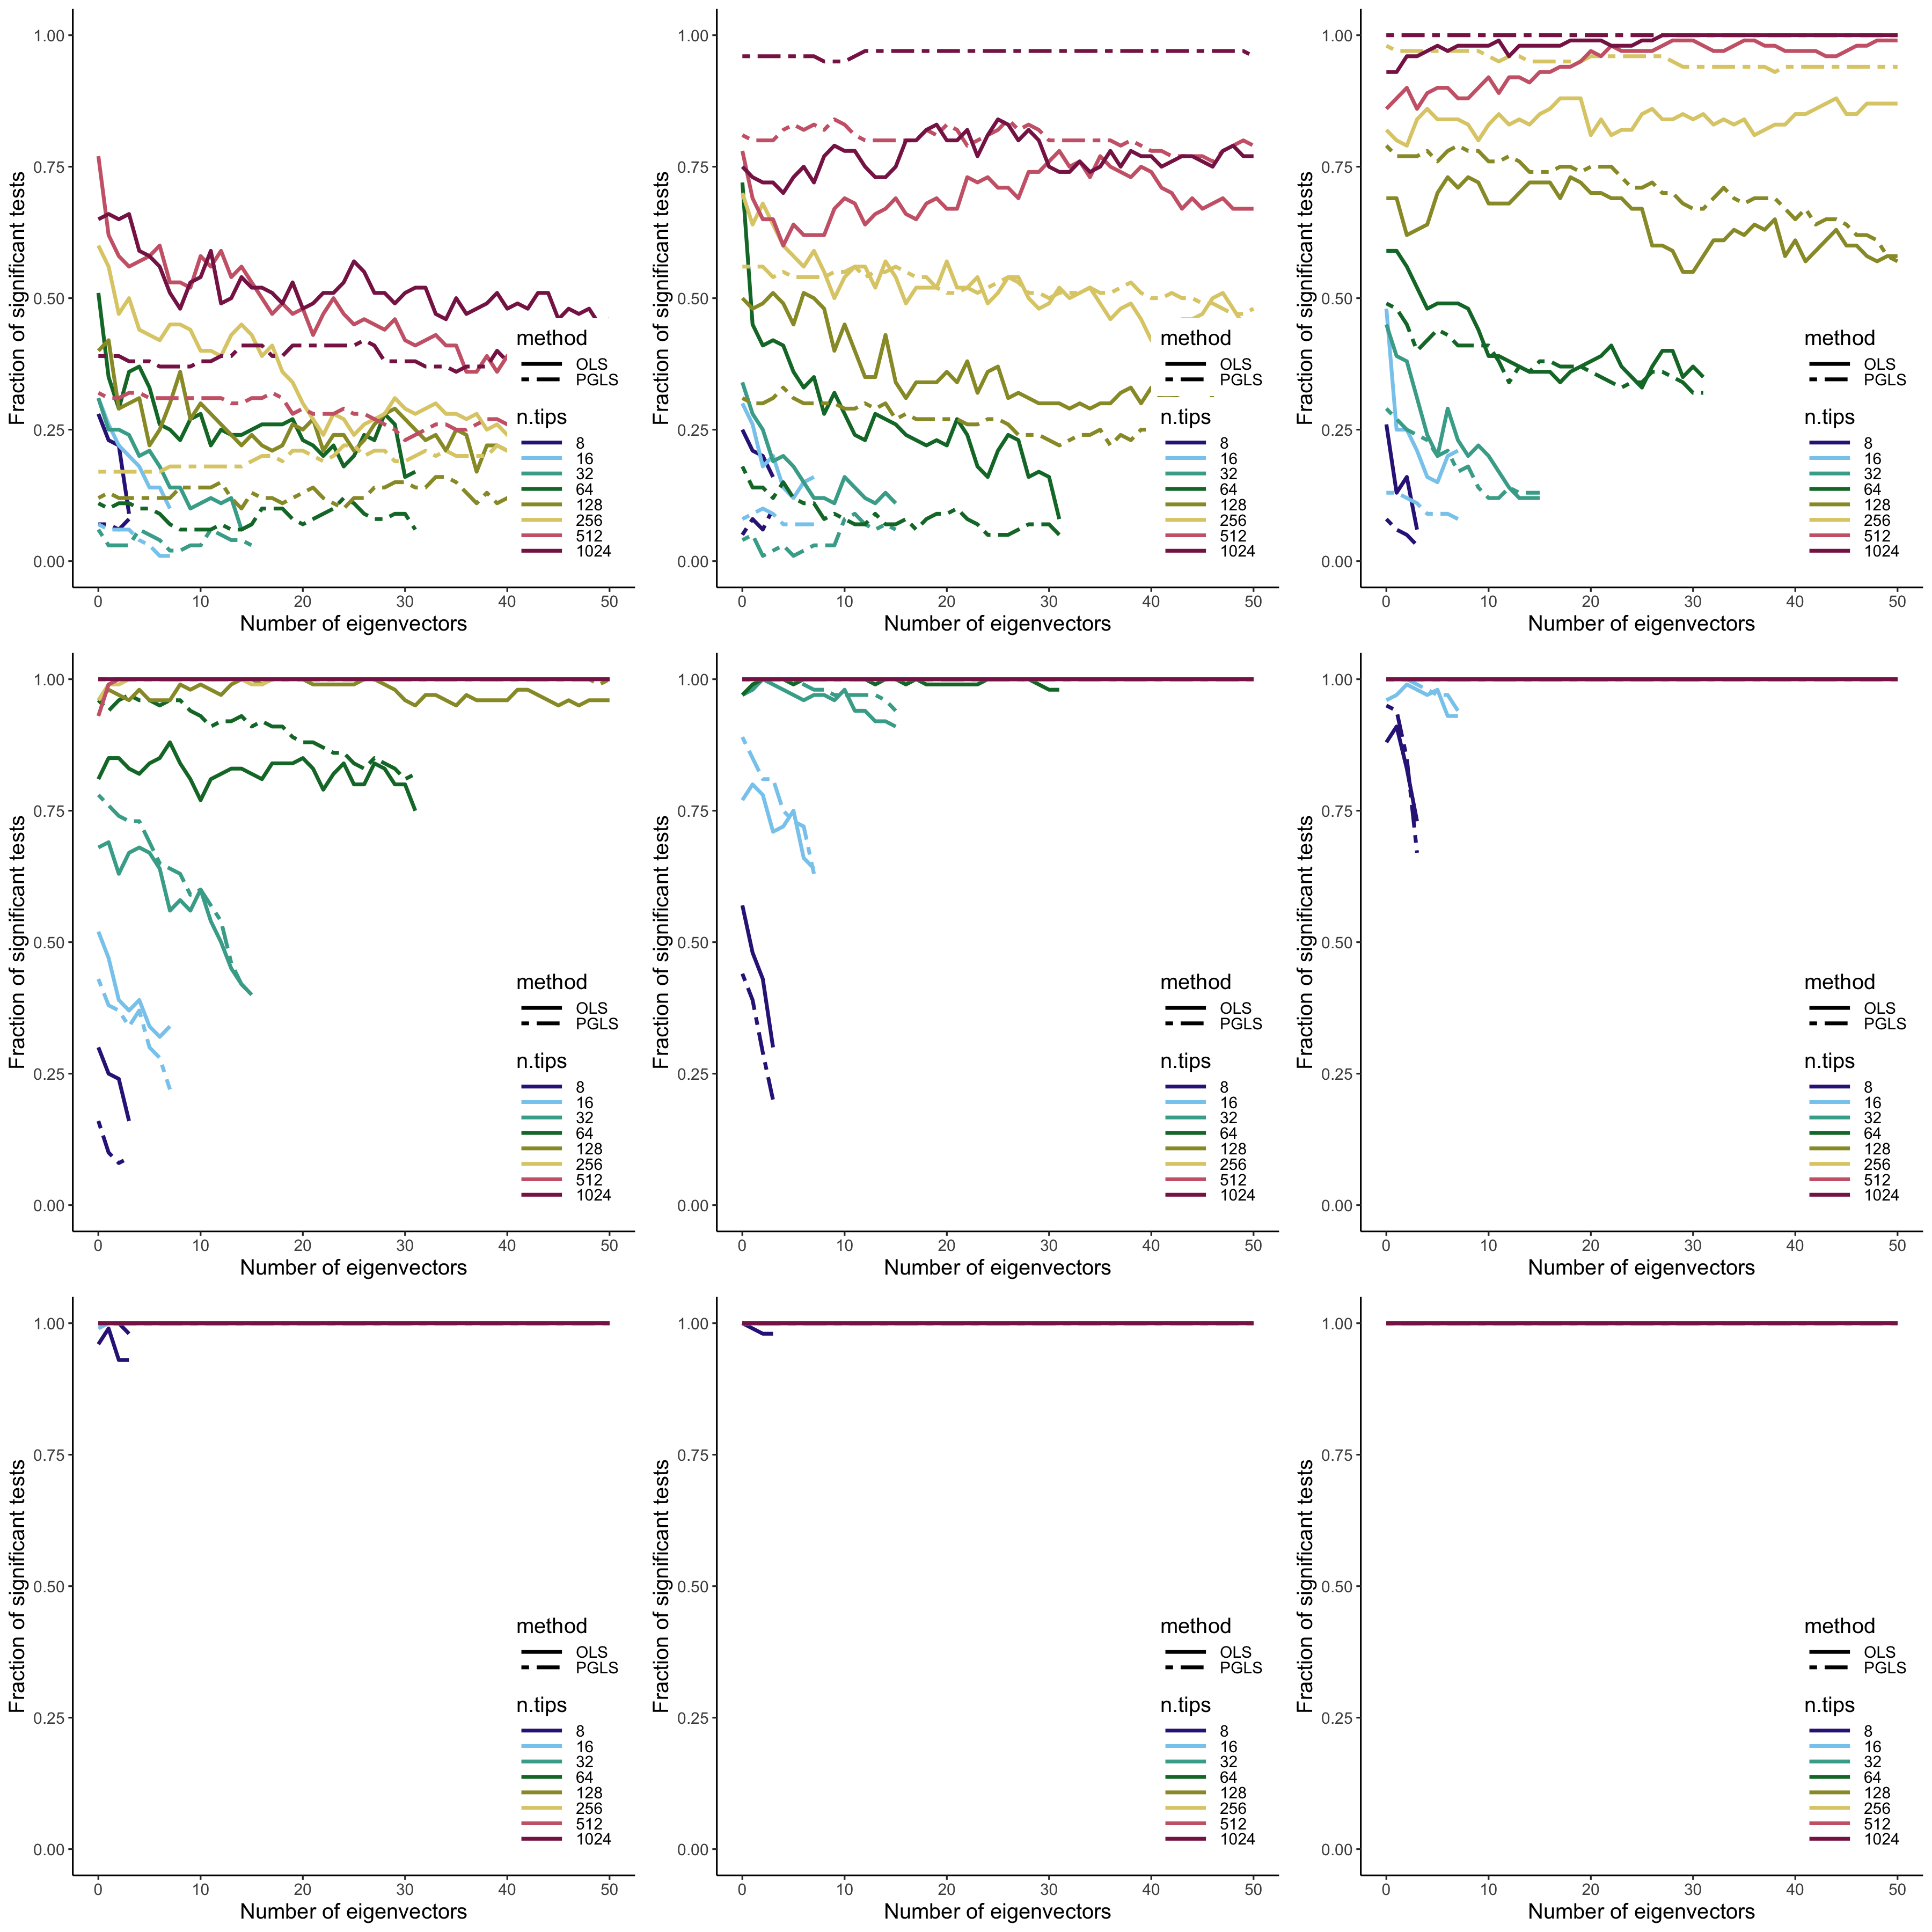

In [34]:
options(repr.plot.width = 30, repr.plot.height = 30)

row1 <- arrangeGrob(plot_positive_yule_list[[1]], plot_positive_yule_list[[2]], plot_positive_yule_list[[3]], ncol = 3)
row2 <- arrangeGrob(plot_positive_yule_list[[4]], plot_positive_yule_list[[5]], plot_positive_yule_list[[6]], ncol = 3)
row3 <- arrangeGrob(plot_positive_yule_list[[7]], plot_positive_yule_list[[8]], plot_positive_yule_list[[9]], ncol = 3)

# Arrange all rows into one layout
g <- grid.arrange(row1, row2, row3, nrow = 3)
g
ggsave("Figures_raw/Supplmentary_scaling_positive_1.pdf", g, width = 30, height = 30)
ggsave("Figures_raw/Supplmentary_scaling_positive_1.svg", g, width = 30, height = 30)